## DATA 620 Project 2
Denise Atherley

## Introduction & Setup
For Project 2 we are asked to identify a large 2-node network dataset that consists of ties between and not within two (or more) distinct groups. Because I already worked with the Davis Southern Women dataset, a standard bipartite network dataset, for my Week 3 assignment, I chose to utilize it for this project as well. I will verify the two distinct node sets: the women and the social events they attended, reduce the size of the network using the island method and make inferences about each distinct group.

In [5]:
import networkx as nx
import networkx.algorithms.bipartite as bipartite
import matplotlib.pyplot as plt

# 1. Load the built-in Davis Southern Women dataset
G = nx.davis_southern_women_graph()

# 2. Extract the two distinct node sets (bipartite groups)
women = G.graph['top']
events = G.graph['bottom']

print(f"Total Nodes: {G.number_of_nodes()}")
print(f"Total Edges: {G.number_of_edges()}")
print(f"Number of Women: {len(women)}")
print(f"Number of Events: {len(events)}")

# Verify the graph is bipartite
print(f"Is bipartite? {bipartite.is_bipartite(G)}")

Total Nodes: 32
Total Edges: 89
Number of Women: 18
Number of Events: 14
Is bipartite? True


## Bipartite Projection
Because the network consists of ties between distinct groups, I cannot apply the Island Method directly to the bipartite graph. Instead, I must project the network into two weighted 1-mode networks:

1. Women's Network: An edge exists between two women if they attended the same event. The weight of the edge is the number of events they co-attended.

2. Events Network: An edge exists between two events if the same woman attended both. The weight is the number of women who attended both.

In [6]:
# Create weighted projected graphs for both groups
W = bipartite.weighted_projected_graph(G, women)
E = bipartite.weighted_projected_graph(G, events)

print(f"Women Projection - Nodes: {W.number_of_nodes()}, Edges: {W.number_of_edges()}")
print(f"Events Projection - Nodes: {E.number_of_nodes()}, Edges: {E.number_of_edges()}")

Women Projection - Nodes: 18, Edges: 139
Events Projection - Nodes: 14, Edges: 66


## Visualizing the Full Projections

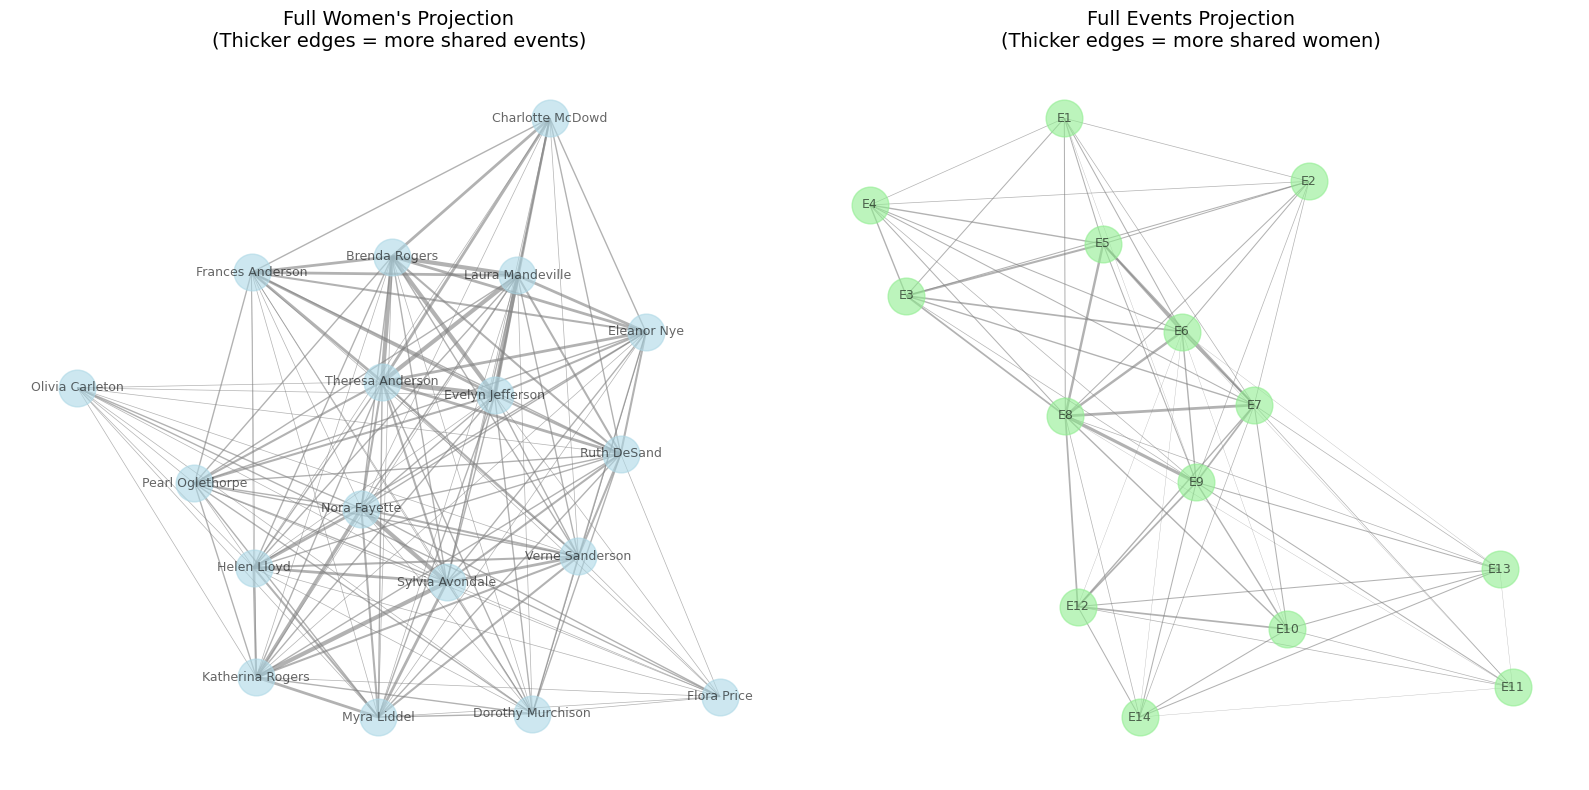

In [7]:
# Create a wide figure for side-by-side comparison
plt.figure(figsize=(16, 8))

# Plot the Full Women's Network
plt.subplot(1, 2, 1)

# Generate a layout for the nodes
pos_w_full = nx.spring_layout(W, k=0.8, seed=42)

# Extract edge weights and scale them down slightly for visual clarity
weights_w = [edata['weight'] for f, to, edata in W.edges(data=True)]
scaled_weights_w = [w * 0.5 for w in weights_w] 

# Draw the graph using the scaled weights for edge thickness
nx.draw(W, pos_w_full, with_labels=True, node_color='lightblue', 
        node_size=700, font_size=9, 
        width=scaled_weights_w, edge_color='gray', alpha=0.6)

plt.title("Full Women's Projection\n(Thicker edges = more shared events)", fontsize=14)

# 2. Plot the Full Events Network
plt.subplot(1, 2, 2)

# Generate a layout for the nodes
pos_e_full = nx.spring_layout(E, k=0.8, seed=42)

# Extract edge weights and scale them down 
# (Event weights get higher, so we scale by a smaller multiplier)
weights_e = [edata['weight'] for f, to, edata in E.edges(data=True)]
scaled_weights_e = [w * 0.25 for w in weights_e]

# Draw the graph using the scaled weights for edge thickness
nx.draw(E, pos_e_full, with_labels=True, node_color='lightgreen', 
        node_size=700, font_size=9, 
        width=scaled_weights_e, edge_color='gray', alpha=0.6)

plt.title("Full Events Projection\n(Thicker edges = more shared women)", fontsize=14)

# Render the plots
plt.tight_layout()
plt.show()

## The Island Method
The projected graphs are extremely dense (almost fully connected) because most women share at least one event with everyone else. The Island Method reduces the size and complexity of the network by setting a "water level" (a threshold). I drop edges that fall below this threshold, revealing the isolated "islands" of core relationships.

In [8]:
def trim_edges(g, weight_threshold):
    """
    Applies the Island Method by creating a new graph containing 
    only edges with a weight greater than or equal to the threshold.
    """
    g_trimmed = nx.Graph()
    for f, to, edata in g.edges(data=True):
        if edata['weight'] >= weight_threshold:
            g_trimmed.add_edge(f, to, weight=edata['weight'])
    return g_trimmed

# Apply the Island Method to the Women's network
# Threshold: Women must have co-attended at least 4 events together
core_women = trim_edges(W, weight_threshold=4)

# Apply the Island Method to the Events network
# Threshold: Events must share at least 6 of the same women
core_events = trim_edges(E, weight_threshold=6)

print(f"Core Women Islands - Nodes: {core_women.number_of_nodes()}, Edges: {core_women.number_of_edges()}")
print(f"Core Event Islands - Nodes: {core_events.number_of_nodes()}, Edges: {core_events.number_of_edges()}")

Core Women Islands - Nodes: 14, Edges: 24
Core Event Islands - Nodes: 6, Edges: 7


## Visualizing the Reduced Networks
Now that I've reduced the size of the network, I will visualize the "islands" to see the core structures that remain after trimming the weaker ties.

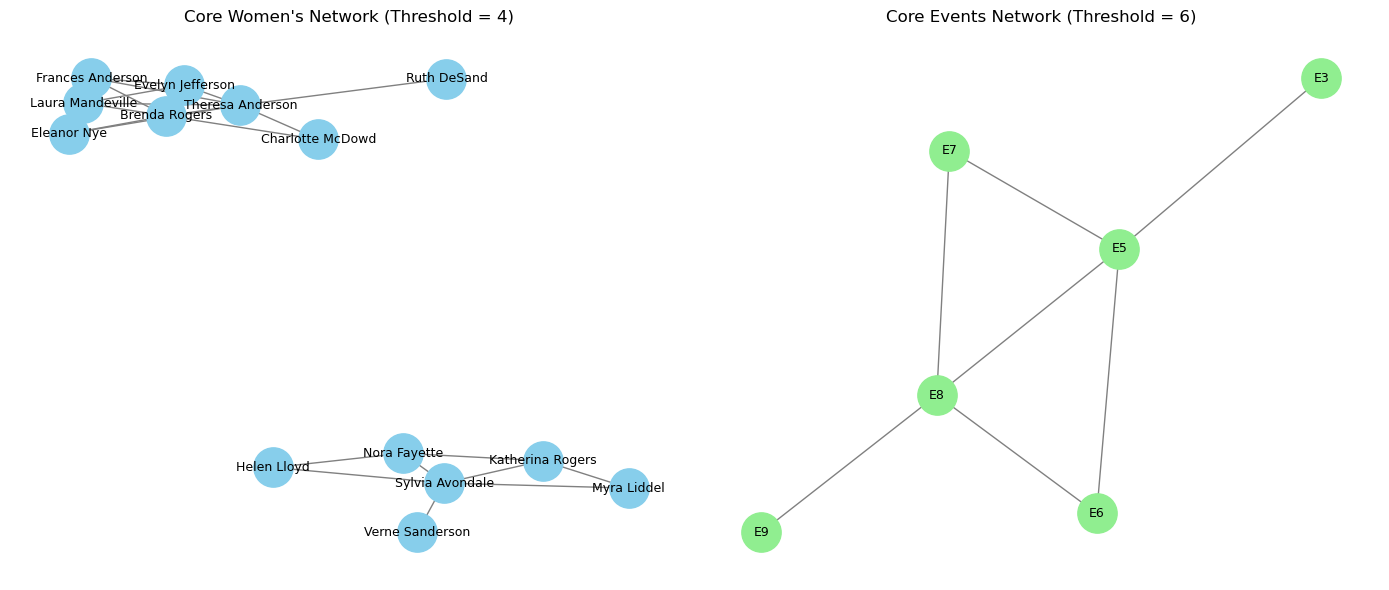

Women's Sub-groups (Islands): [{'Evelyn Jefferson', 'Frances Anderson', 'Theresa Anderson', 'Ruth DeSand', 'Eleanor Nye', 'Brenda Rogers', 'Charlotte McDowd', 'Laura Mandeville'}, {'Nora Fayette', 'Myra Liddel', 'Verne Sanderson', 'Sylvia Avondale', 'Helen Lloyd', 'Katherina Rogers'}]
Events Sub-groups (Islands): [{'E8', 'E7', 'E5', 'E6', 'E9', 'E3'}]


In [9]:
plt.figure(figsize=(14, 6))

# Plot Women's Core Network
plt.subplot(1, 2, 1)
pos_w = nx.spring_layout(core_women, seed=42)
nx.draw(core_women, pos_w, with_labels=True, node_color='skyblue', 
        node_size=800, font_size=9, edge_color='gray')
plt.title("Core Women's Network (Threshold = 4)")

# Plot Events Core Network
plt.subplot(1, 2, 2)
pos_e = nx.spring_layout(core_events, seed=42)
nx.draw(core_events, pos_e, with_labels=True, node_color='lightgreen', 
        node_size=800, font_size=9, edge_color='gray')
plt.title("Core Events Network (Threshold = 6)")

plt.tight_layout()
plt.show()

# Find and print the isolated islands (connected components)
print("Women's Sub-groups (Islands):", list(nx.connected_components(core_women)))
print("Events Sub-groups (Islands):", list(nx.connected_components(core_events)))

## Network Analysis & Inferences
Based on the reduction of the network using the Island Method, we can draw the following inferences about each of the distinct groups:

1. Inferences about the Women (The Key Social Players):

* Identification of Core Cliques: Before applying the Island method, the network was a massive "hairball" where almost everyone was connected. By raising the water level (requiring women to co-attend at least 4 events), sideline individuals dropped off. The remaining nodes (Evelyn, Theresa, Brenda, Sylvia, Nora, etc.) represent the true "social glue" of the community.

- Sub-group Dynamics: Depending on how high we set the threshold, the women's network fractures into distinct sub-cliques. These cliques represent tightly-knit friend groups who move through the social circuit together, highlighting a social hierarchy where a core group dictates the social momentum while peripheral women only interact with the group on the margins.

2. Inferences about the Events (The Social Contexts):

- Event Significance: Not all 14 events hold the same social weight. By filtering for events that share at least 6 of the same women, we identify the "anchor events" (E8, E9).

- Social Milestones: The highly connected events are likely the major milestones of the season (e.g., a major gala, a core club meeting) that the primary social cliques felt obligated to attend. Events that fell away during the Island Method trimming were likely smaller, niche, or personalized gatherings that only attracted specific individuals rather than the larger, intertwined community.